In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
diagnoses_data = pd.read_csv('../data/mimic_data/DIAGNOSES_ICD.csv')
diagnoses_data.head()

,ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD9_CODE
0,1297,109,172335,1.0,40301
1,1298,109,172335,2.0,486
2,1299,109,172335,3.0,58281
3,1300,109,172335,4.0,5855
4,1301,109,172335,5.0,4254


In [ ]:
notes_data = pd.read_csv('../data/mimic_data/NOTEEVENTS.csv',
                         dtype={'CHARTTIME': str, 'STORETIME': str})
notes_data.head()

,ROW_ID,SUBJECT_ID,HADM_ID,CHARTDATE,CHARTTIME,STORETIME,CATEGORY,DESCRIPTION,CGID,ISERROR,TEXT
0,174,22532,167853.0,2151-08-04,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2151-7-16**] Dischar...
1,175,13702,107527.0,2118-06-14,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2118-6-2**] Discharg...
2,176,13702,167118.0,2119-05-25,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2119-5-4**] D...
3,177,13702,196489.0,2124-08-18,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2124-7-21**] ...
4,178,26880,135453.0,2162-03-25,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2162-3-3**] D...


In [10]:
# checking out some of the notes
print(notes_data['TEXT'][0])

Admission Date:  [**2151-7-16**]       Discharge Date:  [**2151-8-4**]


Service:
ADDENDUM:

RADIOLOGIC STUDIES:  Radiologic studies also included a chest
CT, which confirmed cavitary lesions in the left lung apex
consistent with infectious process/tuberculosis.  This also
moderate-sized left pleural effusion.

HEAD CT:  Head CT showed no intracranial hemorrhage or mass
effect, but old infarction consistent with past medical
history.

ABDOMINAL CT:  Abdominal CT showed lesions of
T10 and sacrum most likely secondary to osteoporosis. These can
be followed by repeat imaging as an outpatient.



                            [**First Name8 (NamePattern2) **] [**First Name4 (NamePattern1) 1775**] [**Last Name (NamePattern1) **], M.D.  [**MD Number(1) 1776**]

Dictated By:[**Hospital 1807**]
MEDQUIST36

D:  [**2151-8-5**]  12:11
T:  [**2151-8-5**]  12:21
JOB#:  [**Job Number 1808**]



In [ ]:
# checking data size before removing null rows
print(f"Data size before removing null rows: {notes_data.shape}")

# remove all null rows for the 'TEXT' column
notes_data = notes_data.dropna(subset=['TEXT'])

# checking data size after removing null rows
print(f"Data size after removing null rows: {notes_data.shape}")

Data size before removing null rows: (2083180, 11)
Data size after removing null rows: (2083180, 11)


In [59]:
# creating dataframe to hold joint data  
joint_data = pd.DataFrame()

# inserting notes_data columns
joint_data['HADM_ID'] = notes_data['HADM_ID']
joint_data['TEXT'] = notes_data['TEXT']

# processing diagnoses_data
diagnoses_data_p = diagnoses_data.drop_duplicates(subset=['HADM_ID'])
diagnoses_data_p = diagnoses_data_p.set_index('HADM_ID')

# inserting diagnoses_data columns
joint_data['ICD9_CODE'] = joint_data['HADM_ID'].map(diagnoses_data_p['ICD9_CODE'])
joint_data['ICD9_CODE'].map({False: np.nan, True: True}, inplace=True)

print(joint_data.head())


    HADM_ID                                               TEXT ICD9_CODE
0  167853.0  Admission Date:  [**2151-7-16**]       Dischar...     01193
1  107527.0  Admission Date:  [**2118-6-2**]       Discharg...      5191
2  167118.0  Admission Date:  [**2119-5-4**]              D...      5191
3  196489.0  Admission Date:  [**2124-7-21**]              ...     51884
4  135453.0  Admission Date:  [**2162-3-3**]              D...     80506


True count: 1851243
False count: 231937
Total count: 2083180


Text(0.5, 1.0, 'Count of Non-Null vs Null ICD9_CODE')

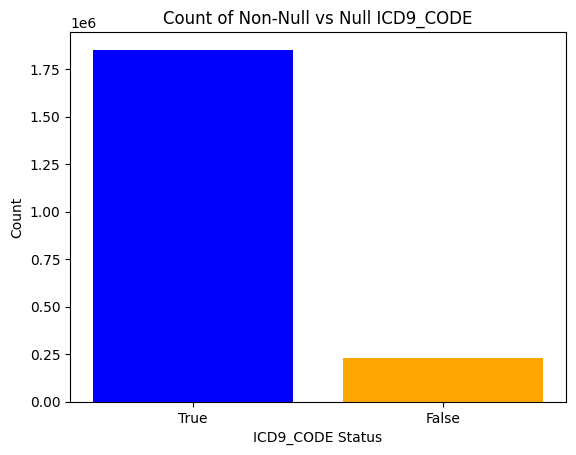

In [60]:
# counting true and false labels
true_cnt = joint_data['ICD9_CODE'].notnull().sum()
false_cnt = joint_data['ICD9_CODE'].isnull().sum()
total_cnt = len(joint_data)
print(f"True count: {true_cnt}")
print(f"False count: {false_cnt}")
print(f"Total count: {total_cnt}")

# plotting bar chart
labels = ['True', 'False']
counts = [true_cnt, false_cnt]
plt.bar(labels, counts, color=['blue', 'orange'])
plt.xlabel('ICD9_CODE Status')
plt.ylabel('Count')
plt.title('Count of Non-Null vs Null ICD9_CODE')

In [61]:
# mapping nulls to false
joint_data['ICD9_CODE'] = joint_data['ICD9_CODE'].notnull()
print(joint_data.head())

# saving joint data to csv
joint_data.to_csv('../data/mimic_data/labeled_data.csv', index=False)

    HADM_ID                                               TEXT  ICD9_CODE
0  167853.0  Admission Date:  [**2151-7-16**]       Dischar...       True
1  107527.0  Admission Date:  [**2118-6-2**]       Discharg...       True
2  167118.0  Admission Date:  [**2119-5-4**]              D...       True
3  196489.0  Admission Date:  [**2124-7-21**]              ...       True
4  135453.0  Admission Date:  [**2162-3-3**]              D...       True


In [ ]:
# extracting true and false samples
true_samples = joint_data[joint_data['ICD9_CODE'] == True]
false_samples = joint_data[joint_data['ICD9_CODE'] == False]

# sampling for testing and training sets
total_samples = len(joint_data)
test_size = int(0.1 * total_samples)
half_test_size = test_size // 2
true_test_samples = true_samples.sample(n=half_test_size, random_state=42)
false_test_samples = false_samples.sample(n=half_test_size, random_state=42)

# creating test set
test_set = pd.concat([true_test_samples, false_test_samples])
print("len of test set: ", len(test_set))

# creating training set
train_set = joint_data.drop(test_set.index).reset_index(drop=True)
print("len of training set: ", len(train_set))

print("len of joint data: ", len(joint_data))

# checking no duplicates
duplicates = test_set.isin(train_set).all(axis=1)
has_duplicates = duplicates.any()
print(f"Test set has duplicates in training set: {has_duplicates}")

test_set.to_csv('../data/mimic_data/test_data.csv', index=False)
train_set.to_csv('../data/mimic_data/train_data.csv', index=False)

len of test set:  208318
len of training set:  1874862
len of joint data:  2083180
Test set has duplicates in training set: False
